# Housing Price Prediction Using Multiple Linear Regression

#### <center> ***Domain: Real Estate***

---

<center><img src="https://raw.githubusercontent.com/Masterx-AI/Project_Housing_Price_Prediction_/main/hs.jpg" style="width: 700px;"/>

---

### Description:

A simple yet challenging project, to predict the housing price based on certain factors like house area, bedrooms, furnished, nearness to mainroad, etc. The dataset is small yet, its complexity arises due to the fact that it has strong multicollinearity.


### Acknowledgement: 
Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.
Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.


### Objective:

The objective of this project is to analyze housing data and build a Multiple Linear Regression model to predict house prices.

---

# <center> Strategic Plan of Action:

**We aim to solve the problem statement by creating a plan of action, Here are some of the necessary steps:**
1. Data Exploration
2. Exploratory Data Analysis (EDA)
3. Data Pre-processing
4. Data Manipulation
5. Feature Selection/Extraction
6. Multiple Linear Regression Modelling
7. Project Outcomes & Conclusion

---

# <center>1. Data Exploration

In [1]:
#Importing the basic libraries

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,6]

import warnings 
warnings.filterwarnings('ignore')

In [21]:
from pathlib import Path

FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures directory:", FIGURES_DIR.resolve())
print("Tables directory:", TABLES_DIR.resolve())

Figures directory: D:\Tài liệu học tập\Năm học 2025-2026\Học kì II 2025-2026\Khoa học dữ liệu\Project_DS\outputs\figures
Tables directory: D:\Tài liệu học tập\Năm học 2025-2026\Học kì II 2025-2026\Khoa học dữ liệu\Project_DS\outputs\tables


In [2]:
#Importing the dataset

df = pd.read_csv("../data/raw/Housing.csv")

display(df.head())

target = 'price'
features = [i for i in df.columns if i not in [target]]

original_df = df.copy(deep=True)

print('\n\033[1mInference:\033[0m The Dataset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Inference: The Dataset consists of 13 features & 545 samples.


In [3]:
#Checking the dtypes of all the columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [4]:
#Checking number of unique rows in each feature

df.nunique().sort_values()

guestroom             2
basement              2
mainroad              2
hotwaterheating       2
airconditioning       2
prefarea              2
furnishingstatus      3
bathrooms             4
parking               4
stories               4
bedrooms              6
price               219
area                284
dtype: int64

In [5]:
#Checking number of unique rows in each feature

nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=16:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Dataset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


Inference: The Dataset has 1 numerical & 11 categorical features.


In [6]:
#Checking the stats of all the columns

display(df.describe())

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Inference:** The stats seem to be fine, let us do further analysis on the Dataset

---

# <center> 2. Exploratory Data Analysis (EDA)

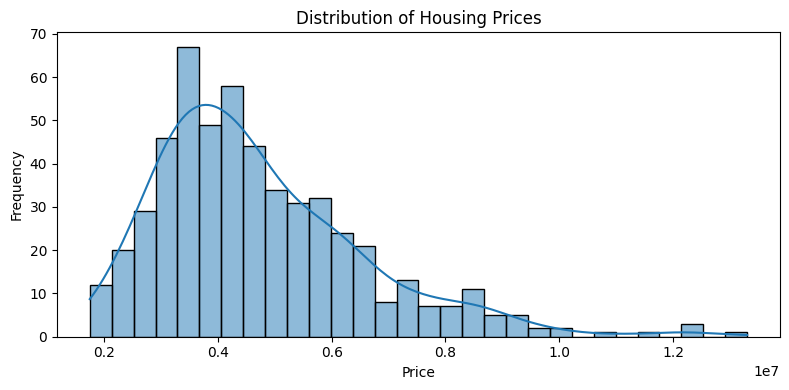

In [23]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x=target,
    bins=30,
    kde=True
)

plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Inference:** The Target Variable seems to be normally distributed, averaging around a central value.

                                 Visualising Categorical Features:                                 


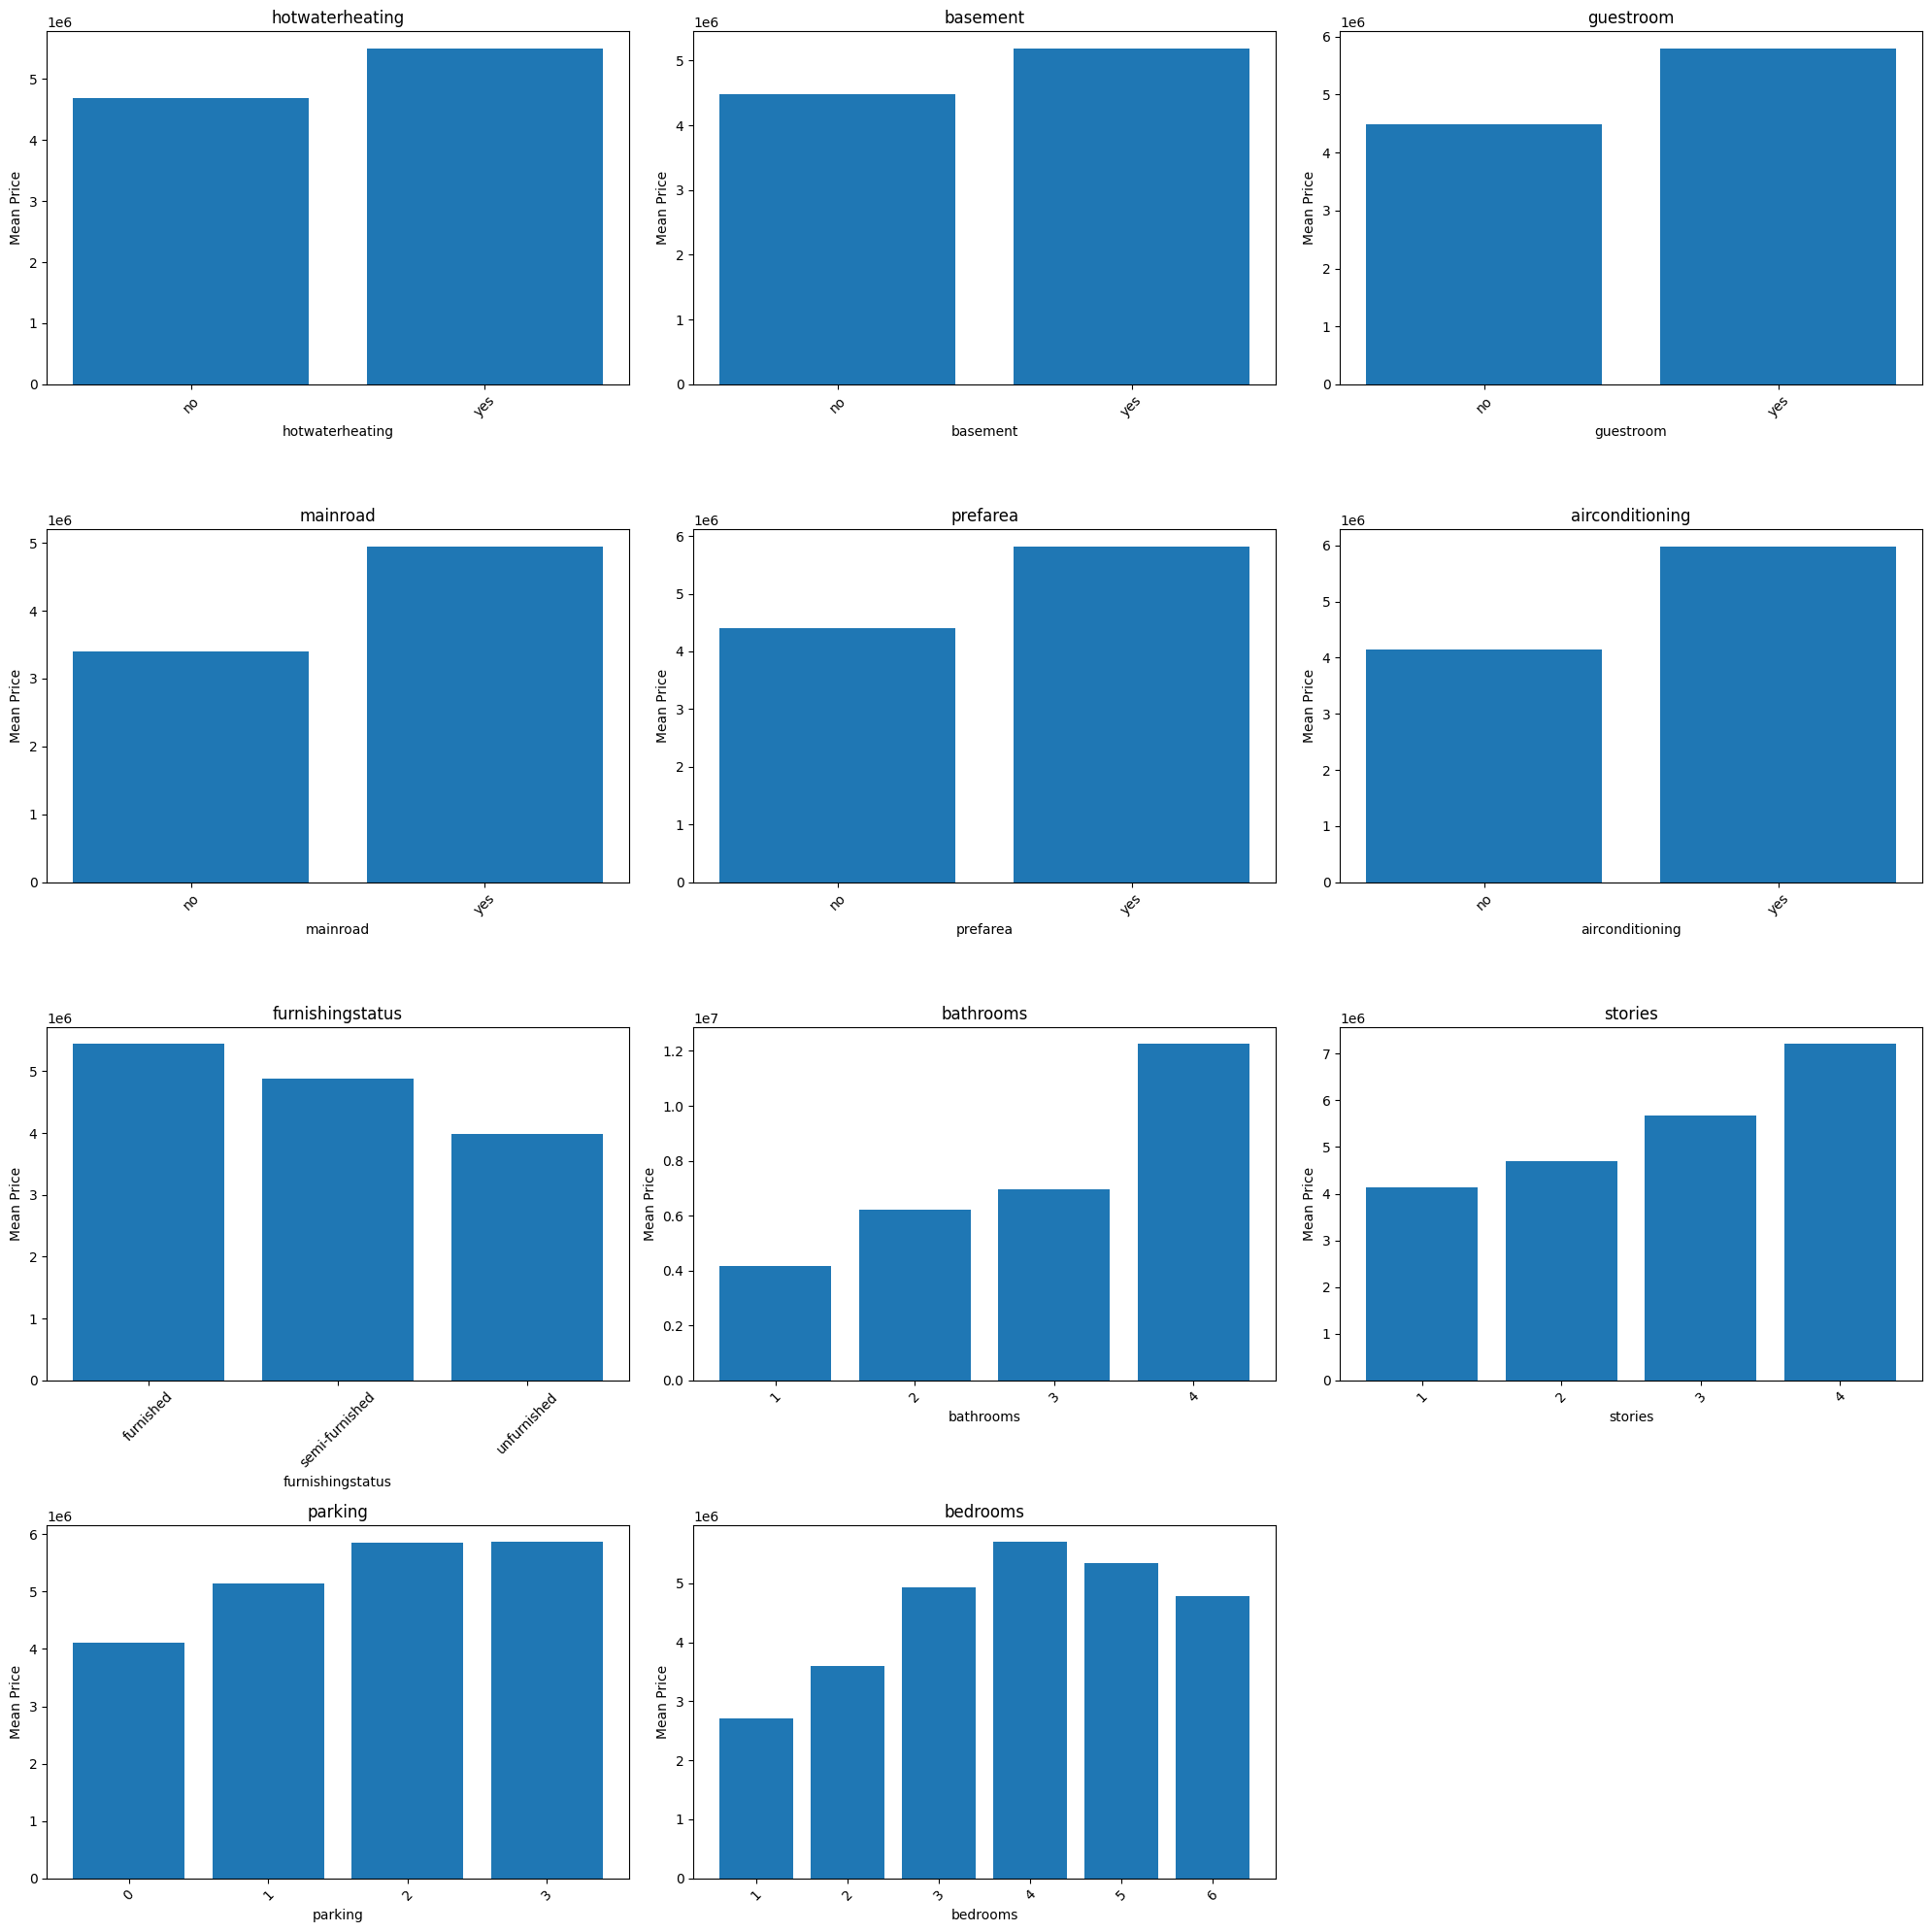

In [24]:
print('\033[1m' + ' ' * 33 + 'Visualising Categorical Features:' + ' ' * 33)

n = len(cf)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))

# Flatten axes để dễ truy cập theo index tuyến tính
if nrows == 1 and ncols == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes.reshape(1, -1)
elif ncols == 1:
    axes = axes.reshape(-1, 1)

for i, col in enumerate(cf):
    ax = axes[i // ncols, i % ncols]
    temp_df = pd.DataFrame(df.groupby([col])[target].mean()).reset_index()
    ax.bar(temp_df[col].astype(str), temp_df[target])
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Mean Price')
    ax.tick_params(axis='x', rotation=45)

# Ẩn các ô subplot dư thừa
for j in range(i + 1, nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "02_categorical_features_mean_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


                                 Visualising Numerical Features:                                 


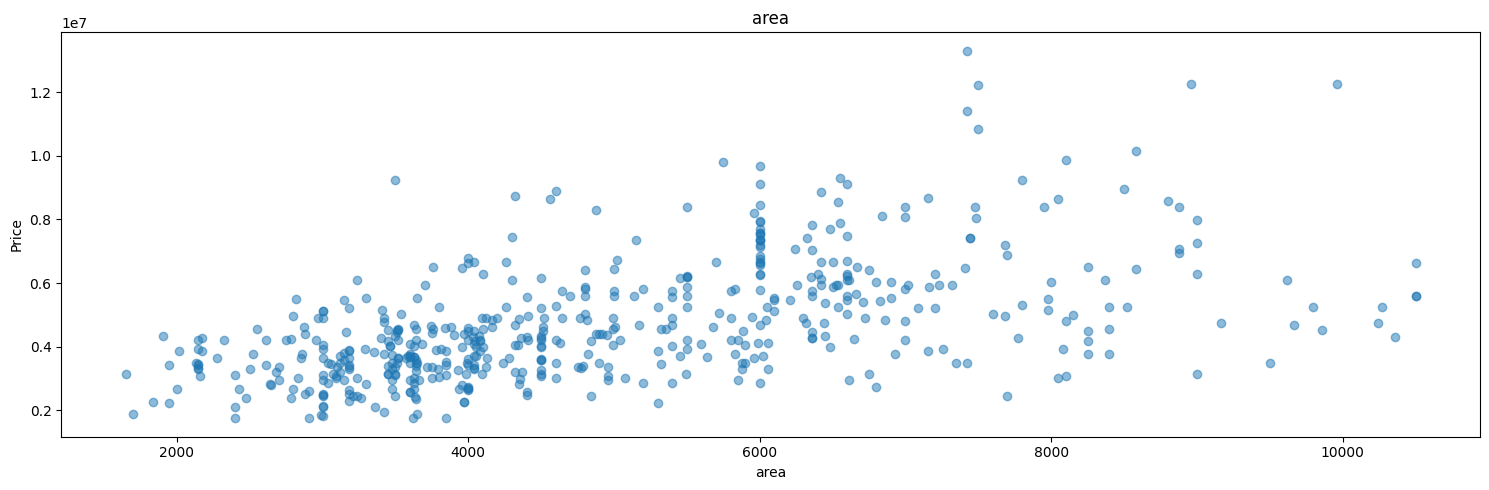

In [25]:
print('\033[1m' + ' ' * 33 + 'Visualising Numerical Features:' + ' ' * 33)

fig, axes = plt.subplots(1, len(nf), figsize=(15, 5))
if len(nf) == 1:
    axes = [axes]
for i, col in enumerate(nf):
    axes[i].scatter(df[col], df[target], alpha=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "03_area_vs_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

# <center> 3. Data Pre-processing

## 3a. Missing Value Analysis

In [10]:
#Checking for missing values

print('\033[1mNull Values Count\033[0m')
print(df.isnull().sum())
print('\n\033[1mInference:\033[0m The Dataset has no missing values.')

Null Values Count
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Inference: The Dataset has no missing values.


## 3b. Duplicate Value Analysis

In [11]:
#Checking for duplicate rows

print('Number of duplicate rows:', df.duplicated().sum())
print('\n\033[1mInference:\033[0m The Dataset has no duplicate rows.')

Number of duplicate rows: 0

Inference: The Dataset has no duplicate rows.


## 3c. Outlier Analysis

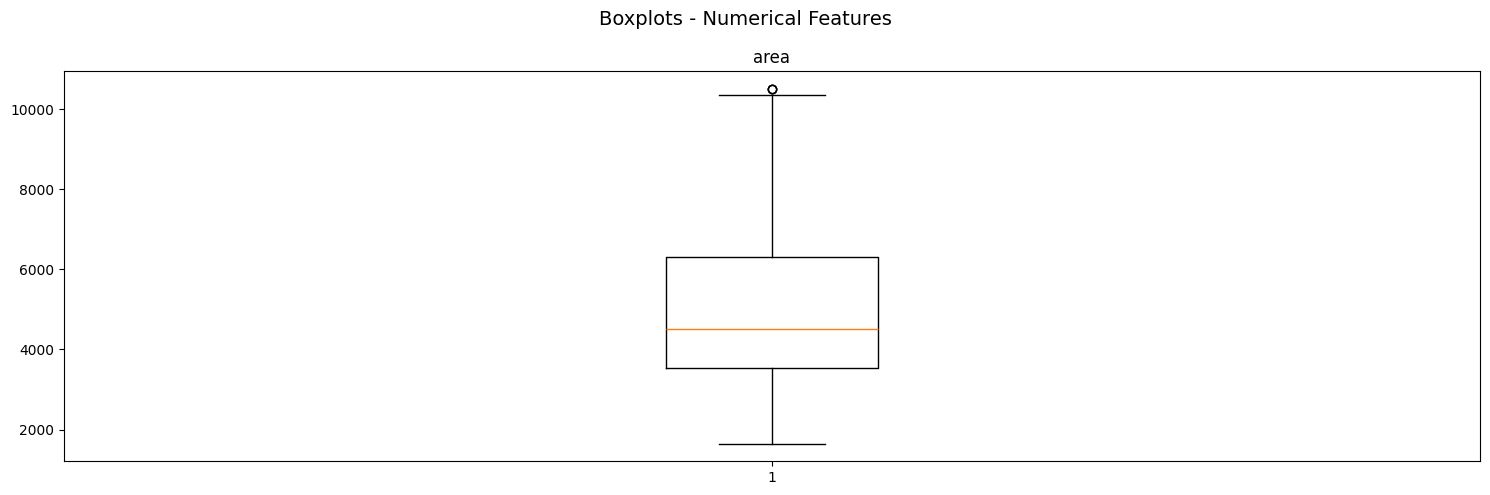

In [28]:
#Visualizing outliers using boxplots

fig, axes = plt.subplots(1, len(nf), figsize=(15, 5))
if len(nf) == 1:
    axes = [axes]
for i, col in enumerate(nf):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
plt.suptitle("Boxplots - Numerical Features", fontsize=14)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_numerical_features_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
#Removing outliers using IQR method

df1 = df.copy()
df3 = df.copy()

for i in df1[nf].columns:
    Q1 = df1[i].quantile(0.25)
    Q3 = df1[i].quantile(0.75)
    IQR = Q3 - Q1
    df1 = df1[df1[i] <= (Q3+(1.5*IQR))]
    df1 = df1[df1[i] >= (Q1-(1.5*IQR))]
    df1 = df1.reset_index(drop=True)
display(df1.head())
print('\n\033[1mInference:\033[0m\nBefore removal of outliers, The dataset had {} samples.'.format(df3.shape[0]))
print('After removal of outliers, The dataset now has {} samples.'.format(df1.shape[0]))

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Inference:
Before removal of outliers, The dataset had 545 samples.
After removal of outliers, The dataset now has 533 samples.


---

# <center> 4. Data Manipulation

In [14]:
#Splitting the data into training & testing sets

df = df1.copy()
df.columns=[i.replace('-','_') for i in df.columns]

m=[]
for i in df.columns.values:
    m.append(i.replace(' ','_'))
    
df.columns = m
X = df.drop([target],axis=1)
Y = df[target]
Train_X, Test_X, Train_Y, Test_Y = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=100)
Train_X.reset_index(drop=True,inplace=True)

print('Original set  --> ',X.shape,Y.shape,'\nTraining set  --> ',Train_X.shape,Train_Y.shape,'\nTesting set   --> ', Test_X.shape,'', Test_Y.shape)

Original set  -->  (533, 12) (533,) 
Training set  -->  (426, 12) (426,) 
Testing set   -->  (107, 12)  (107,)


In [15]:
#Standardization on Training set

print('\033[1m' + ' ' * 41 + 'Standardization on Training set' + ' ' * 41)

# Encoding categorical variables
Train_X = pd.get_dummies(Train_X, drop_first=True)
Test_X = pd.get_dummies(Test_X, drop_first=True)

# Align test set columns with training set
Test_X = Test_X.reindex(columns=Train_X.columns, fill_value=0)

scaler = StandardScaler()
Train_X_std = pd.DataFrame(scaler.fit_transform(Train_X), columns=Train_X.columns)
Test_X_std = pd.DataFrame(scaler.transform(Test_X), columns=Test_X.columns)

display(Train_X_std.describe())

                                         Standardization on Training set                                         


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02,4.260000e+02
mean,-6.463270e-17,-1.709639e-16,1.209257e-16,-6.984502e-17,6.671763e-17,9.799152e-17,-2.501911e-17,1.250956e-17,-3.544374e-17,1.355202e-17,-2.918896e-17,-1.876433e-17,-3.752867e-17
std,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00,1.001176e+00
min,-1.797874e+00,-2.637489e+00,-5.766791e-01,-9.153154e-01,-7.979194e-01,-2.335497e+00,-4.659859e-01,-7.562775e-01,-2.038745e-01,-6.811149e-01,-5.393599e-01,-8.431153e-01,-6.996503e-01
25%,-7.487891e-01,-1.288665e+00,-5.766791e-01,-9.153154e-01,-7.979194e-01,4.281744e-01,-4.659859e-01,-7.562775e-01,-2.038745e-01,-6.811149e-01,-5.393599e-01,-8.431153e-01,-6.996503e-01
50%,-2.551019e-01,6.015882e-02,-5.766791e-01,2.556286e-01,-7.979194e-01,4.281744e-01,-4.659859e-01,-7.562775e-01,-2.038745e-01,-6.811149e-01,-5.393599e-01,-8.431153e-01,-6.996503e-01
75%,6.110159e-01,6.015882e-02,1.436971e+00,2.556286e-01,3.701688e-01,4.281744e-01,-4.659859e-01,1.322266e+00,-2.038745e-01,1.468181e+00,-5.393599e-01,1.186077e+00,1.429286e+00
max,2.992840e+00,4.106631e+00,5.464271e+00,2.597517e+00,2.706345e+00,4.281744e-01,2.145988e+00,1.322266e+00,4.904979e+00,1.468181e+00,1.854050e+00,1.186077e+00,1.429286e+00


---

# <center> 5. Feature Selection

## 5a. Manual Method - VIF (Variance Inflation Factor)

VIF is used to detect multicollinearity among the independent variables. A high VIF value (typically > 10) indicates strong multicollinearity, which may distort the regression coefficients.

In [16]:
#Checking for Multicollinearity using VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = Train_X_std.columns
vif_data["VIF"] = [variance_inflation_factor(Train_X_std.values, i) for i in range(Train_X_std.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print('\n\033[1mVIF Analysis:\033[0m')
display(vif_data)


VIF Analysis:


,Feature,VIF
0,furnishingstatus_unfurnished,1.663829
1,furnishingstatus_semi-furnished,1.585773
2,stories,1.457676
3,area,1.412938
4,bedrooms,1.348307
5,basement_yes,1.322659
6,bathrooms,1.279584
7,airconditioning_yes,1.239193
8,parking,1.218668
9,guestroom_yes,1.215666


## 5b. Automatic Method - RFE (Recursive Feature Elimination)

RFE is used to select the most relevant features for the Multiple Linear Regression model by recursively removing the least important features.

In [17]:
LR = LinearRegression()
rfe = RFE(LR, n_features_to_select=10)
rfe.fit(Train_X_std, Train_Y)

rfe_df = pd.DataFrame({'Feature': Train_X_std.columns, 'Selected': rfe.support_, 'Ranking': rfe.ranking_})
rfe_df = rfe_df.sort_values('Ranking').reset_index(drop=True)
print('\n\033[1mRFE Selected Features:\033[0m')
display(rfe_df)

print('\nSelected features:', list(Train_X_std.loc[:,rfe.support_].columns))

# ✅ Dùng rfe.estimator_ thay vì LR
fitted_LR = rfe.estimator_
print(np.sqrt(mean_squared_error(Train_Y, fitted_LR.predict(Train_X_std.loc[:,rfe.support_]))))
print(np.sqrt(mean_squared_error(Test_Y,  fitted_LR.predict(Test_X_std.loc[:,rfe.support_]))))



RFE Selected Features:


,Feature,Selected,Ranking
0,area,True,1
1,bathrooms,True,1
2,stories,True,1
3,parking,True,1
4,basement_yes,True,1
5,mainroad_yes,True,1
6,airconditioning_yes,True,1
7,hotwaterheating_yes,True,1
8,prefarea_yes,True,1
9,furnishingstatus_unfurnished,True,1



Selected features: ['area', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_unfurnished']
1080025.306294406
981705.6985270559


---

# <center> 6. Predictive Modelling with Multiple Linear Regression

## Objective

Build and evaluate a Multiple Linear Regression model for predicting housing prices using the processed feature set.

In [ ]:
#Let us first define a function to evaluate our model

#Let us first define a function to evaluate our model

model_evaluation = pd.DataFrame(
    index=["Multiple Linear Regression"],
    columns=[
        "Train-R2",
        "Test-R2",
        "Train-RSS",
        "Test-RSS",
        "Train-MSE",
        "Test-MSE",
        "Train-RMSE",
        "Test-RMSE"
    ]
)

rc = np.random.choice(
    Train_X_std.loc[:, Train_X_std.nunique() >= 50].columns.values,
    1,
    replace=False
) if len(Train_X_std.loc[:, Train_X_std.nunique() >= 50].columns) > 0 else Train_X_std.columns[:1]

def evaluate_mlr(train_predictions, test_predictions):
    plt.figure(figsize=(10, 6))

    for i in rc:
        plt.scatter(
            Train_X_std[i],
            Train_Y,
            label='Actual',
            alpha=0.6
        )
        plt.scatter(
            Train_X_std[i],
            train_predictions,
            label='Prediction',
            alpha=0.6
        )
        plt.title(f'Actual vs Predicted Prices by {i}')
        plt.xlabel(i)
        plt.ylabel('Price')
        plt.legend()
        break

    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "05_actual_vs_predicted_by_feature.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    #Evaluating the Multiple Linear Regression Model

    print('\n\n{}Training Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Training set --->',round(r2_score(Train_Y, train_predictions),4))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Train_Y-train_predictions)),4))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Train_Y, train_predictions),4))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Train_Y, train_predictions)),4))

    print('\n{}Testing Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Testing set --->',round(r2_score(Test_Y, test_predictions),4))
    print('Residual Sum of Squares (RSS) on Testing set  --->',round(np.sum(np.square(Test_Y-test_predictions)),4))
    print('Mean Squared Error (MSE) on Testing set       --->',round(mean_squared_error(Test_Y, test_predictions),4))
    print('Root Mean Squared Error (RMSE) on Testing set --->',round(np.sqrt(mean_squared_error(Test_Y, test_predictions)),4))
    print('\n{}Residual Plots{}'.format('-'*20, '-'*20))
    
    model_evaluation.loc['Multiple Linear Regression','Train-R2']  = round(r2_score(Train_Y, train_predictions),4)
    model_evaluation.loc['Multiple Linear Regression','Test-R2']   = round(r2_score(Test_Y, test_predictions),4)
    model_evaluation.loc['Multiple Linear Regression','Train-RSS'] = round(np.sum(np.square(Train_Y-train_predictions)),4)
    model_evaluation.loc['Multiple Linear Regression','Test-RSS']  = round(np.sum(np.square(Test_Y-test_predictions)),4)
    model_evaluation.loc['Multiple Linear Regression','Train-MSE'] = round(mean_squared_error(Train_Y, train_predictions),4)
    model_evaluation.loc['Multiple Linear Regression','Test-MSE']  = round(mean_squared_error(Test_Y, test_predictions),4)
    model_evaluation.loc['Multiple Linear Regression','Train-RMSE']= round(np.sqrt(mean_squared_error(Train_Y, train_predictions)),4)
    model_evaluation.loc['Multiple Linear Regression','Test-RMSE'] = round(np.sqrt(mean_squared_error(Test_Y, test_predictions)),4)

    # Plotting y_test and y_pred to understand the spread.
    plt.figure(figsize=[15,4])

    plt.subplot(1,2,1)
    sns.distplot((Train_Y - train_predictions))
    plt.title('Error Terms')          
    plt.xlabel('Errors') 

    plt.subplot(1,2,2)
    plt.scatter(Train_Y,train_predictions)
    plt.plot([Train_Y.min(),Train_Y.max()],[Train_Y.min(),Train_Y.max()], 'r--')
    plt.title('Train vs Prediction')         
    plt.xlabel('y_train')                       
    plt.ylabel('y_pred')                       
    plt.show()

---

##  Multiple Linear Regression (MLR)

<img src="https://raw.githubusercontent.com/Masterx-AI/Project_BoomBikes_Share_Prediction/main/mr.png" style="width: 600px;float: left;"/>

<<<----------------------------------- Evaluating Multiple Linear Regression Model ----------------------------------->>>

The Coefficient of the Regression Model was found to be  [ 454519.47670008   94916.70123084  460489.39256043  409315.9723115
  232168.45516265  180631.15207713  125209.63964237  154581.2462411
  203729.27169621  380418.99297934  280590.14620338  -11768.52459487
 -177787.15882106]
The Intercept of the Regression Model was found to be  4716708.779342723


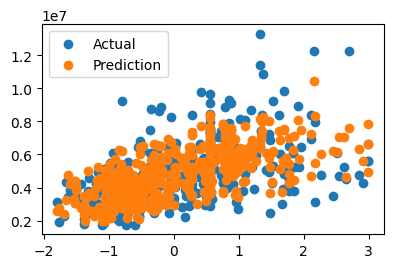



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.6635
Residual Sum of Squares (RSS) on Training set  ---> 488830769715838.7
Mean Squared Error (MSE) on Training set       ---> 1147490069755.4897
Root Mean Squared Error (RMSE) on Training set ---> 1071209.6292

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.7212
Residual Sum of Squares (RSS) on Testing set  ---> 103268906471984.92
Mean Squared Error (MSE) on Testing set       ---> 965129967027.8965
Root Mean Squared Error (RMSE) on Testing set ---> 982410.2845

--------------------Residual Plots--------------------


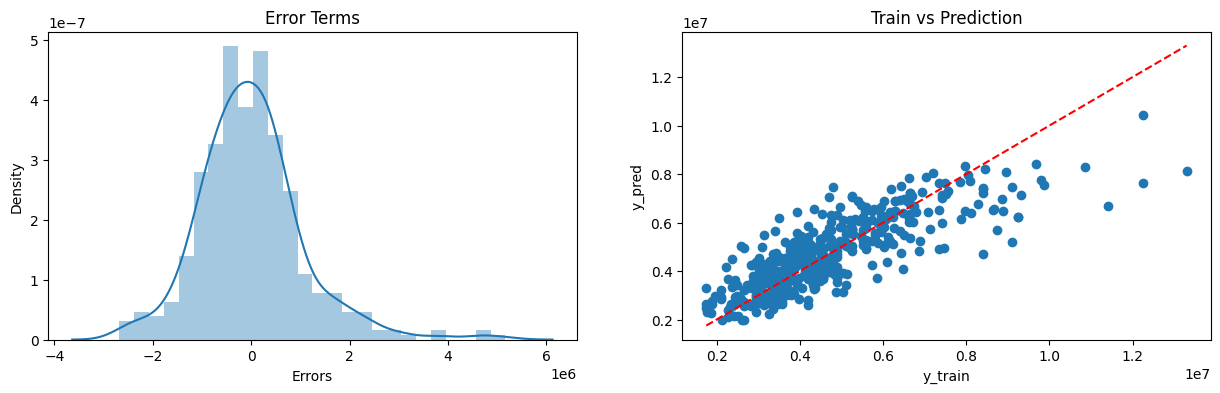

In [19]:
print('<<<-----------------------------------\033[1m Evaluating Multiple Linear Regression Model \033[0m----------------------------------->>>')

MLR = LinearRegression()
MLR.fit(Train_X_std, Train_Y)

train_predictions = MLR.predict(Train_X_std)
test_predictions = MLR.predict(Test_X_std)

print('\nThe Coefficient of the Regression Model was found to be ', MLR.coef_)
print('The Intercept of the Regression Model was found to be ', MLR.intercept_)

evaluate_mlr(train_predictions, test_predictions)

In [20]:
#Model Evaluation Summary

print('\n\033[1mModel Evaluation Results:\033[0m')
display(model_evaluation)


Model Evaluation Results:


,Train-R2,Test-R2,Train-RSS,Test-RSS,Train-MSE,Test-MSE,Train-RMSE,Test-RMSE
Multiple Linear Regression,0.6635,0.7212,488830769715838.6875,103268906471984.921875,1147490069755.489746,965129967027.896484,1071209.6292,982410.2845


---

# <center> 7. Project Outcomes & Conclusion

## Key Outcomes

- The dataset contains 545 housing records with numerical and categorical features.
- Exploratory data analysis identified relationships between housing attributes and price, with features such as area, air conditioning, number of bathrooms, and preferred area showing strong associations with price.
- Categorical variables (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea, furnishingstatus) were encoded using one-hot encoding before model training.
- Outlier removal using the IQR method was applied to reduce the effect of extreme values on the regression model.
- Feature scaling (standardization) was applied to the training set; the same scaler was used to transform the testing set to prevent data leakage.
- Multicollinearity was examined using VIF (Variance Inflation Factor), identifying features with high inter-correlation.
- Relevant features were selected using RFE (Recursive Feature Elimination) with LinearRegression as the estimator.
- A Multiple Linear Regression model was trained to predict housing prices.
- The model was evaluated using R², RSS, MSE, and RMSE on both training and testing sets.
- The difference between training and testing performance was used to assess the model's ability to generalize to unseen data.
- Because the model assumes linear relationships, it may not fully capture complex nonlinear patterns in housing prices.

## Limitations

- The dataset is relatively small (545 records), which may limit generalization.
- Multiple Linear Regression assumes linear relationships between features and the target variable.
- The model is sensitive to multicollinearity and outliers.
- Complex nonlinear patterns in housing prices may not be well captured by a linear model.

## Future Improvements

- Apply cross-validation for more robust model evaluation.
- Perform systematic feature engineering to enrich the feature set.
- Tune the preprocessing pipeline for better data quality.
- Compare the baseline Multiple Linear Regression model with nonlinear algorithms (e.g., Random Forest, Gradient Boosting) as a future extension.